In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from pyproj import Transformer
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

In [2]:
%store

Stored variables and their in-db values:
acc_merge_df                       ->         UnixTimeMillis        device             d
clarity_merge_df                   ->                    drive_id        device  UnixTim
cn0dbhz_merge_df                   ->                    drive_id        device  UnixTim
cn0dbhzdelta_merge_df              ->                    drive_id        device  UnixTim
cn0dbhzmean_merge_df               ->                    drive_id        device  UnixTim
elevationdeg_merge_df              ->                    drive_id        device  UnixTim
gnss_df                            -> '<unavailable>'
gnsskf_df                          ->           utcTimeMillis          device           
gt_df                              ->         UnixTimeMillis          device            
gyro_merge_df                      ->         UnixTimeMillis        device             d
imu_acc_df                         ->           utcTimeMillis  MeasurementX  Measurement
imu_gyro_df    

In [3]:
%store -r cn0dbhz_merge_df
%store -r satcount_merge_df
%store -r elevationdeg_merge_df
%store -r acc_merge_df
%store -r gyro_merge_df
# %store -r energy_merge_df

%store -r satcountdelta_merge_df
# %store -r energydelta_merge_df
%store -r cn0dbhzdelta_merge_df
%store -r cn0dbhzmean_merge_df
# %store -r energystd_merge_df
# %store -r clarity_merge_df

In [4]:
merge_df = cn0dbhz_merge_df.merge(satcount_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'SatCount']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(elevationdeg_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'SvElevationDegrees']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(acc_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'AccMag']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(gyro_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'GyroMag']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
# merge_df = merge_df.merge(energy_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'TotalMotionEnergy']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')

merge_df = merge_df.merge(satcountdelta_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'SatCountDelta']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(cn0dbhzdelta_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'Cn0DbHzDelta']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
# merge_df = merge_df.merge(energydelta_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'EnergyDelta']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
merge_df = merge_df.merge(cn0dbhzmean_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'Cn0DbHzMean']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
# merge_df = merge_df.merge(energystd_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'EnergyStd']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')
# merge_df = merge_df.merge(clarity_merge_df[['UnixTimeMillis', 'drive_id', 'device', 'SignalClarity']], on = ['UnixTimeMillis', 'device', 'drive_id'], how = 'left')

In [5]:
print(merge_df.isna().sum())

drive_id               0
device                 0
UnixTimeMillis         0
Cn0DbHz                0
ErrorXEcefMeters       0
ErrorYEcefMeters       0
ErrorZEcefMeters       0
SatCount               0
SvElevationDegrees    22
AccMag                 0
GyroMag                0
SatCountDelta          0
Cn0DbHzDelta           0
Cn0DbHzMean            0
dtype: int64


In [6]:
# drop null values

# merge_df = merge_df.dropna(subset=['SvElevationDegrees', 'TotalMotionEnergy'])
merge_df = merge_df.dropna(subset=['SvElevationDegrees'])

print(merge_df.isna().sum())
print()
print('Merge Shape: ')
print(merge_df.shape)
print()

drive_id              0
device                0
UnixTimeMillis        0
Cn0DbHz               0
ErrorXEcefMeters      0
ErrorYEcefMeters      0
ErrorZEcefMeters      0
SatCount              0
SvElevationDegrees    0
AccMag                0
GyroMag               0
SatCountDelta         0
Cn0DbHzDelta          0
Cn0DbHzMean           0
dtype: int64

Merge Shape: 
(157514, 14)



In [7]:
X = merge_df[['Cn0DbHz', 'SatCount', 'SvElevationDegrees', 'AccMag', 'GyroMag', 'SatCountDelta', 'Cn0DbHzDelta', 'Cn0DbHzMean']]
y = pd.Series(merge_df['ErrorXEcefMeters'])

In [8]:
# split train and test data with 80% and 20% respectively

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# initial hyperparameters chosen to prevent overfitting

# rf_regressor_x = RandomForestRegressor(
#     n_estimators=300,        # more trees
#     max_depth=7,            # limit depth
#     min_samples_split=3,     # prevent tiny splits
#     min_samples_leaf=2,      # ensure leaves have enough samples
#     max_features='sqrt',     # reduce correlation between trees
#     random_state=42
# )

rf_regressor_x = RandomForestRegressor(
    n_estimators=500,           # Higher count to stabilize the "averaging" with 153k rows
    max_depth=9,               # Increased from 7 to capture non-linearity, but capped
    min_samples_leaf=50,        # CRITICAL: Forces each leaf to represent a statistically significant group (approx 0.03% of your data)
    max_features=0.3,           # Try 30% of features instead of 'sqrt' to give each tree more "context" per split
    bootstrap=True,
    n_jobs=-1,                  # Use all cores for speed
    random_state=42
)

rf_regressor_x.fit(X_train, y_train)

y_train_pred = rf_regressor_x.predict(X_train)
y_test_pred = rf_regressor_x.predict(X_test)

In [10]:
# metrics for train data

print('Goodness of Fit of Model \tTrain Dataset')
print("Explained Variance (R^2) \t:", rf_regressor_x.score(X_train, y_train)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_train, y_train_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.2820594942248581
Mean Squared Error (MSE) 	: 2.723409626534039
Root Mean Squared Error (RMSE) 	: 1.6502756213839067


In [11]:
# metrics for test data

print('Goodness of Fit of Model \tTest Dataset')
print("Explained Variance (R^2) \t:", rf_regressor_x.score(X_test, y_test)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_test, y_test_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.2772686267039607
Mean Squared Error (MSE) 	: 2.822162835925199
Root Mean Squared Error (RMSE) 	: 1.6799294139710748


/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_3458/1815905796.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])


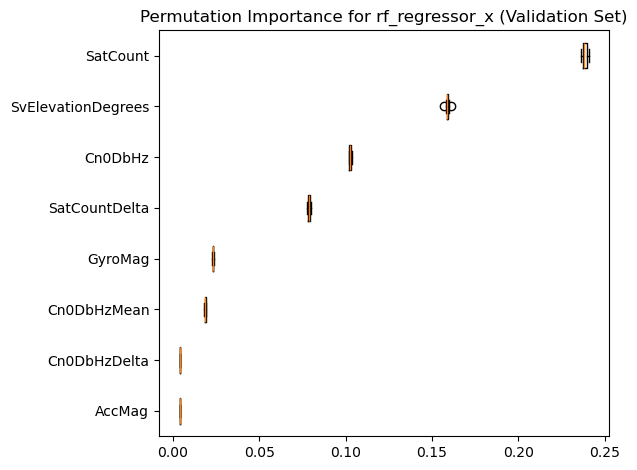

In [12]:
result = permutation_importance(
    rf_regressor_x, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1
)

# Sort and plot
sorted_idx = result.importances_mean.argsort()
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])
plt.title("Permutation Importance for rf_regressor_x (Validation Set)")
plt.tight_layout()
plt.show()

In [13]:
# rf_regressor_randcv = RandomForestRegressor(random_state=42)

# search_space = {
#     'n_estimators' : [100, 150, 200, 250, 300],
#     'max_depth' : [5, 10, 15, None],
#     'min_samples_split' : [2, 5, 10],
#     'min_samples_leaf' : [1, 2, 4],
#     'max_features' : ['sqrt', 'log2', None]
# }

In [14]:
# randsearch_cv = RandomizedSearchCV(
#     estimator = rf_regressor_randcv,
#     param_distributions = search_space,
#     n_iter = 50,
#     cv = 5,
#     scoring = 'r2',
#     n_jobs = -1,
#     verbose = 2,
#     random_state = 42
# )

# randsearch_cv.fit(X_train, y_train)

In [15]:
# print("Best params:", randsearch_cv.best_params_)

In [16]:
# modelx = randsearch_cv.best_estimator_

# y_test_pred = modelx.predict(X_test)

In [17]:
# # metrics for test data

# print('Goodness of Fit of Model \tTest Dataset')
# print("Explained Variance (R^2) \t:", modelx.score(X_test, y_test)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

# mse = mean_squared_error(y_test, y_test_pred)
# print("Mean Squared Error (MSE) \t:", mse)
# print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

In [18]:
X = merge_df[['Cn0DbHz', 'SatCount', 'SvElevationDegrees', 'AccMag', 'GyroMag', 'SatCountDelta', 'Cn0DbHzDelta', 'Cn0DbHzMean']]
y = pd.Series(merge_df['ErrorYEcefMeters'])

In [19]:
# split train and test data with 80% and 20% respectively

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# initial hyperparameters chosen to prevent overfitting

# rf_regressor_y = RandomForestRegressor(
#     n_estimators=300,        # more trees
#     max_depth=7,            # limit depth
#     min_samples_split=3,     # prevent tiny splits
#     min_samples_leaf=2,      # ensure leaves have enough samples
#     max_features='sqrt',     # reduce correlation between trees
#     random_state=42
# )

rf_regressor_y = RandomForestRegressor(
    n_estimators=500,           # Higher count to stabilize the "averaging" with 153k rows
    max_depth=9,               # Increased from 7 to capture non-linearity, but capped
    min_samples_leaf=50,        # CRITICAL: Forces each leaf to represent a statistically significant group (approx 0.03% of your data)
    max_features=0.3,           # Try 30% of features instead of 'sqrt' to give each tree more "context" per split
    bootstrap=True,
    n_jobs=-1,                  # Use all cores for speed
    random_state=42
)

rf_regressor_y.fit(X_train, y_train)

y_train_pred = rf_regressor_y.predict(X_train)
y_test_pred = rf_regressor_y.predict(X_test)

In [21]:
# metrics for train data

print('Goodness of Fit of Model \tTrain Dataset')
print("Explained Variance (R^2) \t:", rf_regressor_y.score(X_train, y_train)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_train, y_train_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.20307303587710535
Mean Squared Error (MSE) 	: 5.180799400387155
Root Mean Squared Error (RMSE) 	: 2.2761369467558747


In [22]:
# metrics for test data

print('Goodness of Fit of Model \tTest Dataset')
print("Explained Variance (R^2) \t:", rf_regressor_y.score(X_test, y_test)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_test, y_test_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.19526059287107478
Mean Squared Error (MSE) 	: 5.2778292624379874
Root Mean Squared Error (RMSE) 	: 2.297352663923845


/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_3458/2674780486.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])


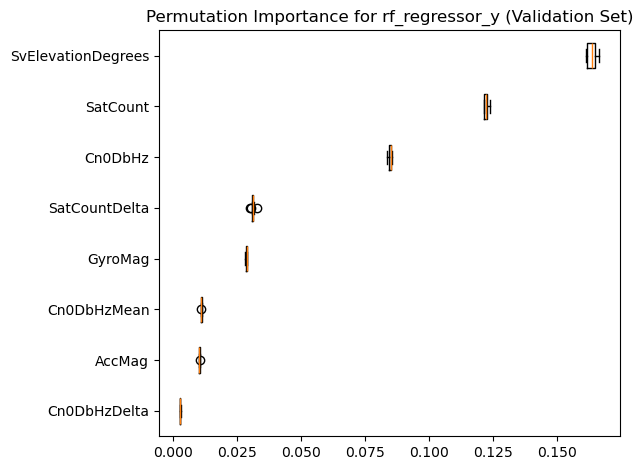

In [23]:
result = permutation_importance(
    rf_regressor_y, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1
)

# Sort and plot
sorted_idx = result.importances_mean.argsort()
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])
plt.title("Permutation Importance for rf_regressor_y (Validation Set)")
plt.tight_layout()
plt.show()

In [24]:
# rf_regressor_randcv = RandomForestRegressor(random_state=42)

# search_space = {
#     'n_estimators' : [100, 150, 200, 250, 300],
#     'max_depth' : [5, 10, 15, None],
#     'min_samples_split' : [2, 5, 10],
#     'min_samples_leaf' : [1, 2, 4],
#     'max_features' : ['sqrt', 'log2', None]
# }

In [25]:
# randsearch_cv = RandomizedSearchCV(
#     estimator = rf_regressor_randcv,
#     param_distributions = search_space,
#     n_iter = 50,
#     cv = 5,
#     scoring = 'r2',
#     n_jobs = -1,
#     verbose = 2,
#     random_state = 42
# )

# randsearch_cv.fit(X_train, y_train)

In [26]:
# print("Best params:", randsearch_cv.best_params_)

In [27]:
# modely = randsearch_cv.best_estimator_

# y_test_pred = modely.predict(X_test)

In [28]:
# # metrics for test data

# print('Goodness of Fit of Model \tTest Dataset')
# print("Explained Variance (R^2) \t:", modelx.score(X_test, y_test)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

# mse = mean_squared_error(y_test, y_test_pred)
# print("Mean Squared Error (MSE) \t:", mse)
# print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

In [29]:
X = merge_df[['Cn0DbHz', 'SatCount', 'SvElevationDegrees', 'AccMag', 'GyroMag', 'SatCountDelta', 'Cn0DbHzDelta', 'Cn0DbHzMean']]
y = pd.Series(merge_df['ErrorZEcefMeters'])

In [30]:
# split train and test data with 80% and 20% respectively

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# initial hyperparameters chosen to prevent overfitting

# rf_regressor_z = RandomForestRegressor(
#     n_estimators=300,        # more trees
#     max_depth=7,            # limit depth
#     min_samples_split=3,     # prevent tiny splits
#     min_samples_leaf=2,      # ensure leaves have enough samples
#     max_features='sqrt',     # reduce correlation between trees
#     random_state=42
# )

rf_regressor_z = RandomForestRegressor(
    n_estimators=500,           # Higher count to stabilize the "averaging" with 153k rows
    max_depth=9,               # Increased from 7 to capture non-linearity, but capped
    min_samples_leaf=50,        # CRITICAL: Forces each leaf to represent a statistically significant group (approx 0.03% of your data)
    max_features=0.3,           # Try 30% of features instead of 'sqrt' to give each tree more "context" per split
    bootstrap=True,
    n_jobs=-1,                  # Use all cores for speed
    random_state=42
)

rf_regressor_z.fit(X_train, y_train)

y_train_pred = rf_regressor_z.predict(X_train)
y_test_pred = rf_regressor_z.predict(X_test)

In [32]:
# metrics for train data

print('Goodness of Fit of Model \tTrain Dataset')
print("Explained Variance (R^2) \t:", rf_regressor_z.score(X_train, y_train)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_train, y_train_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.23616106037321893
Mean Squared Error (MSE) 	: 5.12098995098281
Root Mean Squared Error (RMSE) 	: 2.2629604395531993


In [33]:
# metrics for test data

print('Goodness of Fit of Model \tTest Dataset')
print("Explained Variance (R^2) \t:", rf_regressor_z.score(X_test, y_test)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

mse = mean_squared_error(y_test, y_test_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.23213981018436525
Mean Squared Error (MSE) 	: 5.1685948565228585
Root Mean Squared Error (RMSE) 	: 2.273454388485254


/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_3458/801268078.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])


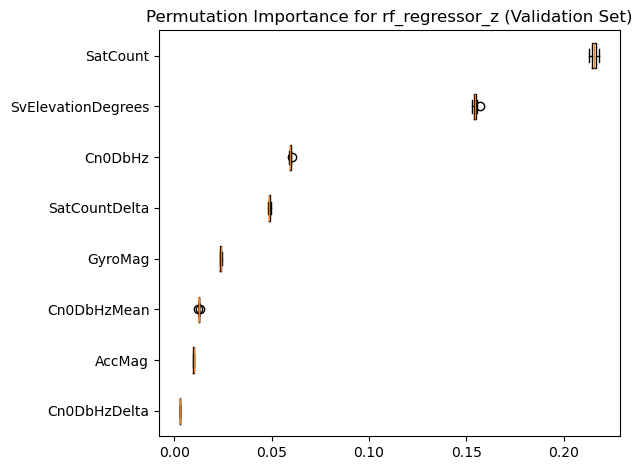

In [34]:
result = permutation_importance(
    rf_regressor_z, X_train, y_train, n_repeats=10, random_state=42, n_jobs=-1
)

# Sort and plot
sorted_idx = result.importances_mean.argsort()
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])
plt.title("Permutation Importance for rf_regressor_z (Validation Set)")
plt.tight_layout()
plt.show()

In [35]:
# rf_regressor_randcv = RandomForestRegressor(random_state=42)

# search_space = {
#     'n_estimators' : [100, 150, 200, 250, 300],
#     'max_depth' : [5, 10, 15, None],
#     'min_samples_split' : [2, 5, 10],
#     'min_samples_leaf' : [1, 2, 4],
#     'max_features' : ['sqrt', 'log2', None]
# }

In [36]:
# randsearch_cv = RandomizedSearchCV(
#     estimator = rf_regressor_randcv,
#     param_distributions = search_space,
#     n_iter = 50,
#     cv = 5,
#     scoring = 'r2',
#     n_jobs = -1,
#     verbose = 2,
#     random_state = 42
# )

# randsearch_cv.fit(X_train, y_train)

In [37]:
# print("Best params:", randsearch_cv.best_params_)

In [38]:
# modelz = randsearch_cv.best_estimator_

# y_test_pred = modelz.predict(X_test)

In [39]:
# # metrics for test data

# print('Goodness of Fit of Model \tTest Dataset')
# print("Explained Variance (R^2) \t:", modelx.score(X_test, y_test)) # tells you how accurate your model is fitting the data, the closer it is to 1, the better the fit.

# mse = mean_squared_error(y_test, y_test_pred)
# print("Mean Squared Error (MSE) \t:", mse)
# print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse)) 

In [40]:
%store -r merge_test_df

In [41]:
print(merge_test_df.isna().sum())

UnixTimeMillis        0
Cn0DbHz               0
SatCount              0
SvElevationDegrees    0
tripId                0
AccMag                0
GyroMag               0
SatCountDelta         0
Cn0DbHzDelta          0
Cn0DbHzMean           0
x_kf                  0
y_kf                  0
z_kf                  0
dtype: int64


In [42]:
# features_test_df = merge_test_df.drop(columns=['UnixTimeMillis', 'tripId', 'WlsPositionXEcefMeters','WlsPositionYEcefMeters', 'WlsPositionZEcefMeters'])

# predicted_errorx = modelx.predict(features_test_df)
# predicted_errory = modely.predict(features_test_df)
# predicted_errorz = modelz.predict(features_test_df)

# print('predicted_errorx: ')
# print(predicted_errorx)
# print()
# print('predicted_errory: ')
# print(predicted_errory)
# print()
# print('predicted_errorz: ')
# print(predicted_errorz)
# print()

In [43]:
# submission_ecef = pd.DataFrame()
# submission_ecef['MeasurementX_Corr'] = merge_test_df['WlsPositionXEcefMeters'] + predicted_errorx
# submission_ecef['MeasurementY_Corr'] = merge_test_df['WlsPositionYEcefMeters'] + predicted_errory
# submission_ecef['MeasurementZ_Corr'] = merge_test_df['WlsPositionZEcefMeters'] + predicted_errorz

In [44]:
# transformer = Transformer.from_crs("EPSG:4978", "EPSG:4326", always_xy=True)

# lon, lat, alt = transformer.transform(
#     submission_ecef['MeasurementX_Corr'].values, 
#     submission_ecef['MeasurementY_Corr'].values,
#     submission_ecef['MeasurementZ_Corr'].values,
# )

In [45]:
# submission = pd.DataFrame()
# submission['tripId'] = merge_test_df['tripId']
# submission['UnixTimeMillis'] = merge_test_df['UnixTimeMillis']
# submission['LatitudeDegrees'] = lat
# submission['LongitudeDegrees'] = lon

# print(submission)
# print()
# submission.to_csv('./SUBMISSIONS/RANDOM_FOREST/submission.csv', index=False)

In [47]:
features_test_df = merge_test_df.drop(columns=['UnixTimeMillis', 'tripId', 'x_kf','y_kf', 'z_kf'])

predicted_errorx = rf_regressor_x.predict(features_test_df)
predicted_errory = rf_regressor_y.predict(features_test_df)
predicted_errorz = rf_regressor_z.predict(features_test_df)

print('predicted_errorx: ')
print(predicted_errorx)
print()
print('predicted_errory: ')
print(predicted_errory)
print()
print('predicted_errorz: ')
print(predicted_errorz)
print()

predicted_errorx: 
[ 0.29839233  0.26408817  0.21701184 ... -1.21891637 -1.26199757
 -1.43147277]

predicted_errory: 
[-1.04526643 -1.18858798 -1.15765792 ... -1.66722925 -1.71755577
 -1.79205397]

predicted_errorz: 
[0.34801339 0.36531513 0.29289663 ... 0.48678029 0.54994248 0.75461733]



In [49]:
submission_ecef = pd.DataFrame()
submission_ecef['MeasurementX_Corr'] = merge_test_df['x_kf'] + predicted_errorx
submission_ecef['MeasurementY_Corr'] = merge_test_df['y_kf'] + predicted_errory
submission_ecef['MeasurementZ_Corr'] = merge_test_df['z_kf'] + predicted_errorz

In [50]:
transformer = Transformer.from_crs("EPSG:4978", "EPSG:4326", always_xy=True)

lon, lat, alt = transformer.transform(
    submission_ecef['MeasurementX_Corr'].values, 
    submission_ecef['MeasurementY_Corr'].values,
    submission_ecef['MeasurementZ_Corr'].values,
)

In [51]:
submission = pd.DataFrame()
submission['tripId'] = merge_test_df['tripId']
submission['UnixTimeMillis'] = merge_test_df['UnixTimeMillis']
submission['LatitudeDegrees'] = lat
submission['LongitudeDegrees'] = lon

print(submission)
print()

                                          tripId  UnixTimeMillis  \
0      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650832999   
1      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650833999   
2      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650834999   
3      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650835999   
4      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650836999   
...                                          ...             ...   
66092           2022-04-25-US-OAK-2/GooglePixel4   1650927742650   
66093           2022-04-25-US-OAK-2/GooglePixel4   1650927743642   
66094           2022-04-25-US-OAK-2/GooglePixel4   1650927744651   
66095           2022-04-25-US-OAK-2/GooglePixel4   1650927745640   
66096           2022-04-25-US-OAK-2/GooglePixel4   1650927746632   

       LatitudeDegrees  LongitudeDegrees  
0            37.395760       -122.102960  
1            37.395759       -122.102960  
2            37.395758       -122.102961  
3          

In [52]:
def remove_spikes(df):
    dist_lat = df.groupby('tripId')['LatitudeDegrees'].diff().abs()
    dist_lng = df.groupby('tripId')['LongitudeDegrees'].diff().abs()
    
    mask = (dist_lat > 0.0005) | (dist_lng > 0.0005)
    
    df.loc[mask, ['LatitudeDegrees', 'LongitudeDegrees']] = np.nan
    
    return df.groupby('tripId').apply(lambda group: group.interpolate())

In [53]:
def apply_savgol_filter(df, window=11, poly=3):
    df = df.reset_index(drop=True)
    df_out = df.copy()
    
    for trip_id, trip_df in df_out.groupby('tripId'):
        
        if len(trip_df) > window:
            df_out.loc[trip_df.index, 'LatitudeDegrees'] = savgol_filter(trip_df['LatitudeDegrees'], window, poly)
            df_out.loc[trip_df.index, 'LongitudeDegrees'] = savgol_filter(trip_df['LongitudeDegrees'], window, poly)

    return df_out

In [54]:
submission = remove_spikes(submission)
submission = apply_savgol_filter(submission)

/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_3458/2132394206.py:9: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  return df.groupby('tripId').apply(lambda group: group.interpolate())
/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_3458/2132394206.py:9: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  return df.groupby('tripId').apply(lambda group: group.interpolate())
/var/folders/w8/d9x92py92j792gw_1kyfc8sh0000gn/T/ipykernel_3458/2132394206.py:9: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  return df.groupby('tripId').apply(lambda group: group.interpolate())
/var/folders/w8/d9x92py92j792gw_1k

In [55]:
print(submission)
print()
submission.to_csv('./SUBMISSIONS/RANDOM_FOREST/submission.csv', index=False)

                                          tripId  UnixTimeMillis  \
0      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650832999   
1      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650833999   
2      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650834999   
3      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650835999   
4      2021-04-28-US-MTV-2/SamsungGalaxyS20Ultra   1619650836999   
...                                          ...             ...   
66092           2022-04-25-US-OAK-2/GooglePixel4   1650927742650   
66093           2022-04-25-US-OAK-2/GooglePixel4   1650927743642   
66094           2022-04-25-US-OAK-2/GooglePixel4   1650927744651   
66095           2022-04-25-US-OAK-2/GooglePixel4   1650927745640   
66096           2022-04-25-US-OAK-2/GooglePixel4   1650927746632   

       LatitudeDegrees  LongitudeDegrees  
0            37.395759       -122.102958  
1            37.395760       -122.102963  
2            37.395759       -122.102962  
3          